# 02. ROSE and LROM Cross Section Comparison

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext
import numpy as np
import pandas as pd

# Resolve imports whether execution starts from the repository or notebook directory.
ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom_legacy").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import benchmark_helper
import lrom_legacy.v2_0 as lrom

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
LOG_FORMATTER = LogFormatterMathtext(base=10)

## 1. System Setup

In [4]:
# Physical system, shared design, and comparison grids.
TARGET = (40, 20)
PROJECTILE = (1, 0)
LAB_ENERGY = 14.1
L_MAX = 10
MESH_SIZE = 600
N_TRAIN = 200
N_TEST = 100
HALF_WIDTH = 0.20
ANGLES_DEG = np.arange(1.0, 180.0, 1.0)
BASIS_SIZES = (4, 6, 8)
ROSE_EIM_SIZES = (4, 8, 12)
LROM_OPERATOR_COUNTS = (4, 8, 12)
DEFAULT_BASIS_SIZE = 6
DEFAULT_OPERATOR_COUNT = 8
POTENTIAL_ELL = 2
POTENTIAL_RADIUS_LIMITS_FM = (0.5, 12.0)
TIMING_REPEATS = 3
TIMING_INNER_LOOPS = 20
SEED = 1204
ERROR_DENOMINATOR_FLOOR = 1e-12
PLOTTING_FLOOR = 1e-6
LS_LABEL = "LS-projected cross section"

## 2. Training and Testing Samples

In [5]:
# The parked-v2 emulator supplies one shared high-fidelity design to every method.
emulator = lrom.LROM(
    target=TARGET,
    projectile=PROJECTILE,
    lab_energy=LAB_ENERGY,
    l=tuple(range(L_MAX + 1)),
    potential="full_woods-saxon",
)

central = dict(emulator.central_parameters)
ranges = {
    name: tuple(
        sorted(((1.0 - HALF_WIDTH) * value, (1.0 + HALF_WIDTH) * value))
    )
    for name, value in central.items()
}

# All radii returned by sampling are physical fm; no scaled coordinate is plotted.
emulator.sampling(
    training_ranges=ranges,
    testing_ranges=ranges,
    training_size=N_TRAIN,
    testing_size=N_TEST,
    mesh_size=MESH_SIZE,
    strategy="latin_hypercube",
    seed=SEED,
    high_fidelity_solver="runge_kutta",
    solver_options={"rk_tols": (1e-9, 1e-9)},
)

In [6]:
# Preserve ordered arrays for solvers and named dictionaries for public prediction calls.
design = emulator.samples.design
parameter_names = emulator.parameter_names
train_rows = design.training.values.copy()
test_rows = design.testing.values.copy()
train_ids = design.training.case_ids
test_ids = design.testing.case_ids

train_cases = [
    {name: float(value) for name, value in zip(parameter_names, row)}
    for row in train_rows
]
test_cases = [
    {name: float(value) for name, value in zip(parameter_names, row)}
    for row in test_rows
]

assert train_rows.shape == (N_TRAIN, len(parameter_names))
assert test_rows.shape == (N_TEST, len(parameter_names))
assert not any(np.array_equal(a, b) for a in train_rows for b in test_rows)

## 3. Potential and LROM Operator Locations

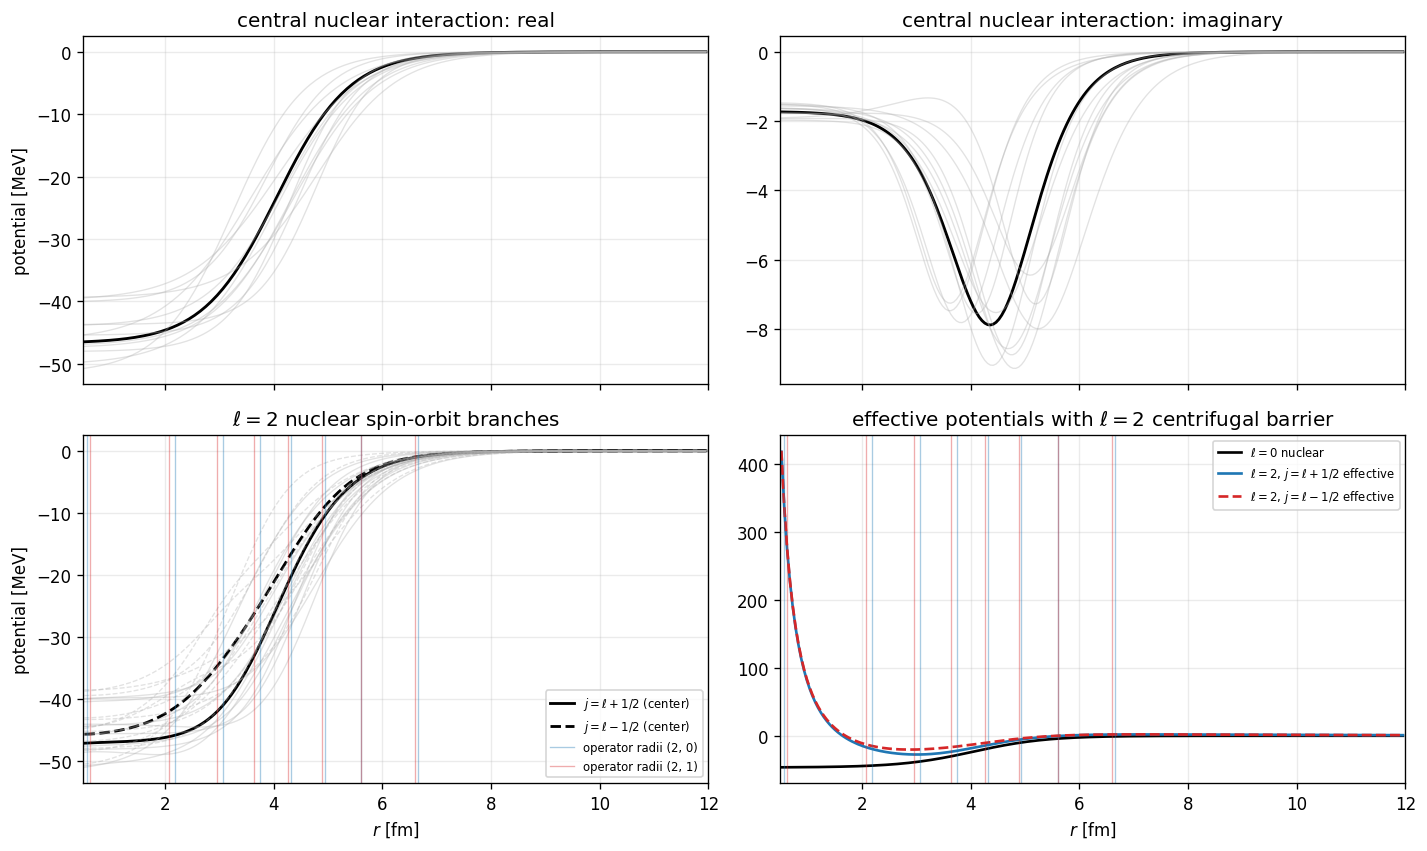

In [7]:
mesh = emulator.samples.mesh
radius_mesh = mesh.radius
plot_mask = (
    (radius_mesh >= POTENTIAL_RADIUS_LIMITS_FM[0])
    & (radius_mesh <= POTENTIAL_RADIUS_LIMITS_FM[1])
)
plot_radius = radius_mesh[plot_mask]
center_vector = np.array([central[name] for name in parameter_names])

# These are the exact operator locations expected from the default LROM fit.
displayed_predictors = lrom.build_effective_interaction_predictors(
    full_order_models=emulator.samples.full_order_models,
    rho=mesh.rho,
    radius=radius_mesh,
    central_values=center_vector,
    training_values=train_rows,
    testing_values=test_rows,
    predictor_count=DEFAULT_OPERATOR_COUNT,
    minimum_radius=0.5,
)

# Use the center plus a normalized spread of held-out potentials for context.
range_scale = np.array([ranges[name][1] - ranges[name][0] for name in parameter_names])
distance = np.linalg.norm((test_rows - center_vector) / range_scale, axis=1)
ranked = np.argsort(distance)
potential_rows = np.vstack(
    [center_vector, test_rows[ranked[np.linspace(0, len(ranked) - 1, 12, dtype=int)]]]
)

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.2), sharex=True)
for row_index, row in enumerate(potential_rows):
    central_potential = lrom.full_woods_saxon(radius_mesh, row)
    spin_orbit_form = lrom.full_woods_saxon_spin_orbit(radius_mesh, row)
    barrier = benchmark_helper.centrifugal_barrier_mev(
        radius_mesh,
        ell=POTENTIAL_ELL,
        reduced_mass_mev=emulator.kinematics.mu,
    )
    nuclear_plus = central_potential + POTENTIAL_ELL * spin_orbit_form
    nuclear_minus = central_potential - (POTENTIAL_ELL + 1) * spin_orbit_form
    context_style = {"color": "0.68", "alpha": 0.35, "lw": 0.8}
    style = {"color": "black", "alpha": 1.0, "lw": 1.7} if row_index == 0 else context_style
    label_suffix = " (center)" if row_index == 0 else None

    axes[0, 0].plot(plot_radius, central_potential.real[plot_mask], **style)
    axes[0, 1].plot(plot_radius, central_potential.imag[plot_mask], **style)
    axes[1, 0].plot(
        plot_radius,
        nuclear_plus.real[plot_mask],
        **style,
        label=r"$j=\ell+1/2$" + label_suffix if label_suffix else None,
    )
    axes[1, 0].plot(
        plot_radius,
        nuclear_minus.real[plot_mask],
        linestyle="--",
        **style,
        label=r"$j=\ell-1/2$" + label_suffix if label_suffix else None,
    )
    if row_index == 0:
        axes[1, 1].plot(
            plot_radius,
            central_potential.real[plot_mask],
            color="black",
            lw=1.6,
            label=r"$\ell=0$ nuclear",
        )
        axes[1, 1].plot(
            plot_radius,
            (nuclear_plus.real + barrier)[plot_mask],
            color="tab:blue",
            lw=1.6,
            label=r"$\ell=2$, $j=\ell+1/2$ effective",
        )
        axes[1, 1].plot(
            plot_radius,
            (nuclear_minus.real + barrier)[plot_mask],
            color="tab:red",
            linestyle="--",
            lw=1.6,
            label=r"$\ell=2$, $j=\ell-1/2$ effective",
        )

# Show only the ell=2 operator radii on the two panels where channel separation matters.
for color, channel in zip(("tab:blue", "tab:red"), ((POTENTIAL_ELL, 0), (POTENTIAL_ELL, 1))):
    state = displayed_predictors[channel]
    for radius_index, selected_radius in enumerate(state.selected_radii):
        for ax in axes[1]:
            ax.axvline(
                selected_radius,
                color=color,
                alpha=0.38,
                lw=0.8,
                label=f"operator radii {channel}" if ax is axes[1, 0] and radius_index == 0 else None,
            )

for ax, title in zip(
    axes.flat,
    (
        "central nuclear interaction: real",
        "central nuclear interaction: imaginary",
        r"$\ell=2$ nuclear spin-orbit branches",
        r"effective potentials with $\ell=2$ centrifugal barrier",
    ),
):
    ax.set_title(title)
    ax.set_xlim(*POTENTIAL_RADIUS_LIMITS_FM)
for ax in axes[1]:
    ax.set_xlabel(r"$r$ [fm]")
for ax in axes[:, 0]:
    ax.set_ylabel("potential [MeV]")
axes[1, 0].legend(fontsize=7)
axes[1, 1].legend(fontsize=7)
fig.tight_layout()

selected_radii = np.concatenate(
    [state.selected_radii for state in displayed_predictors.values()]
)
assert np.all(selected_radii >= 0.5)
plt.show()

## 4. ROSE Pipeline

In [8]:
# This is the only high-level ROSE construction/evaluation call in the notebook.
rose_pipeline = benchmark_helper.RoseCrossSectionPipeline(
    emulator=emulator,
    training_rows=train_rows,
    testing_rows=test_rows,
    angles_degrees=ANGLES_DEG,
    denominator_floor=ERROR_DENOMINATOR_FLOOR,
    timing_repeats=TIMING_REPEATS,
    timing_inner_loops=TIMING_INNER_LOOPS,
)
rose_comparison = rose_pipeline.run(
    basis_sizes=BASIS_SIZES,
    eim_sizes=ROSE_EIM_SIZES,
)

rose_emulators = rose_comparison.emulators
reference_sae = rose_emulators[(BASIS_SIZES[0], ROSE_EIM_SIZES[0])]
fom_train_xs = rose_comparison.fom_training_cross_sections
fom_test_xs = rose_comparison.fom_testing_cross_sections
rose_results = rose_comparison.results
default_key = (DEFAULT_BASIS_SIZE, DEFAULT_OPERATOR_COUNT)

rose_channel_counts = benchmark_helper.validate_partial_wave_topology(
    reference_sae.rbes,
    l_max=L_MAX,
)
benchmark_helper.validate_configuration_grid(
    rose_results,
    basis_sizes=BASIS_SIZES,
    compression_sizes=ROSE_EIM_SIZES,
    label="ROSE",
)
assert rose_channel_counts == (1,) + (2,) * L_MAX
assert fom_train_xs.shape == (N_TRAIN, ANGLES_DEG.size)
assert fom_test_xs.shape == (N_TEST, ANGLES_DEG.size)

## 5. LROM and Least-Squares Pipelines

In [9]:
# LROM training is deliberately outside the ROSE pipeline and owns its timings.
lrom_study = benchmark_helper.LromCrossSectionStudy(
    emulator=emulator,
    training_cases=train_cases,
    testing_cases=test_cases,
    training_rows=train_rows,
    testing_rows=test_rows,
    fom_training_cross_sections=fom_train_xs,
    fom_testing_cross_sections=fom_test_xs,
    angles_degrees=ANGLES_DEG,
    denominator_floor=ERROR_DENOMINATOR_FLOOR,
    timing_repeats=TIMING_REPEATS,
    timing_inner_loops=TIMING_INNER_LOOPS,
)

old_v2_comparison = lrom_study.run_parked_v2_reference(
    basis_size=DEFAULT_BASIS_SIZE,
    operator_count=DEFAULT_OPERATOR_COUNT,
)
lrom_comparison = lrom_study.run_lrom(
    basis_sizes=BASIS_SIZES,
    operator_counts=LROM_OPERATOR_COUNTS,
    capture_predictors_at=default_key,
)
ls_comparison = lrom_study.run_ls(
    basis_sizes=BASIS_SIZES,
    operator_count=LROM_OPERATOR_COUNTS[0],
)

old_v2_results = old_v2_comparison.results
lrom_results = lrom_comparison.results
archive_lrom_results = lrom_results
default_predictors = lrom_comparison.predictors
ls_results = ls_comparison.results

benchmark_helper.validate_configuration_grid(
    lrom_results,
    basis_sizes=BASIS_SIZES,
    compression_sizes=LROM_OPERATOR_COUNTS,
    label="LROM",
)
validated_predictor_radii = benchmark_helper.validate_predictor_radii(
    displayed_predictors,
    default_predictors,
)
for result in (*rose_results.values(), *lrom_results.values()):
    assert result["train_xs"].shape == (N_TRAIN, ANGLES_DEG.size)
    assert result["test_xs"].shape == (N_TEST, ANGLES_DEG.size)
for result in ls_results.values():
    assert result["train_xs"].shape == (N_TRAIN, ANGLES_DEG.size)
    assert result["test_xs"].shape == (N_TEST, ANGLES_DEG.size)

# Performance is a regenerated diagnostic, not a scientific invariant.
default_lrom_median_error = float(
    np.median(lrom_results[default_key]["test_median_over_angle_error"])
)
default_old_v2_median_error = float(
    np.median(old_v2_results[default_key]["test_median_over_angle_error"])
)
performance_diagnostic = {
    "LROM default median pointwise error": default_lrom_median_error,
    "parked-v2 default median pointwise error": default_old_v2_median_error,
    "LROM minus parked-v2": default_lrom_median_error - default_old_v2_median_error,
}
performance_diagnostic

{'LROM default median pointwise error': 0.003633414903994156,
 'parked-v2 default median pointwise error': 0.0657324847520667,
 'LROM minus parked-v2': -0.062099069848072536}

## 6. Representative Cross Sections

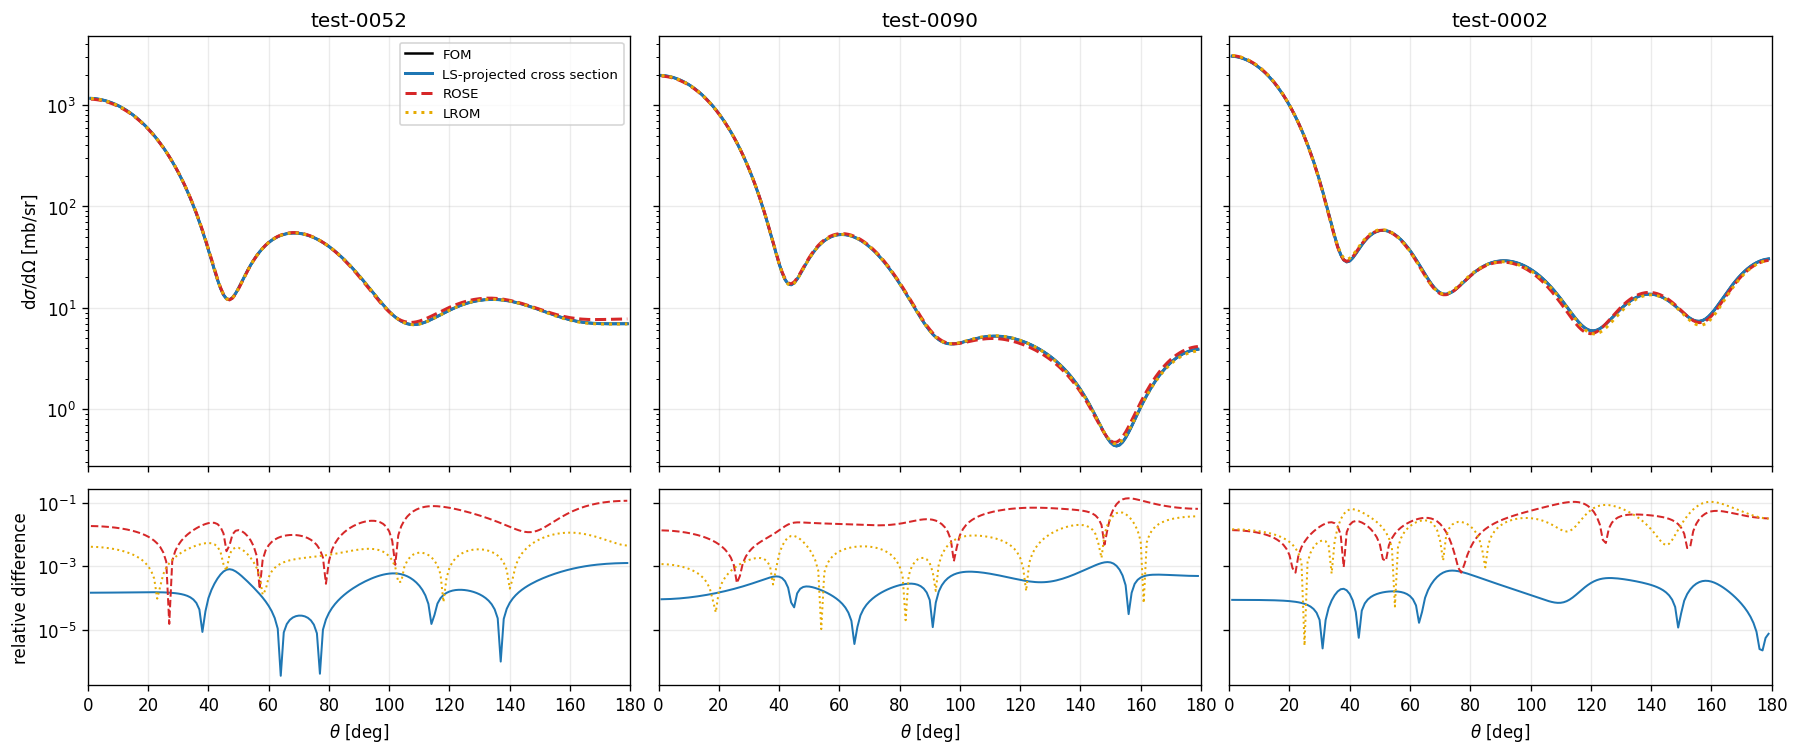

In [11]:
# Select three cases spanning the joint ROSE/LROM error ranking.
lrom_rank = np.argsort(np.argsort(lrom_results[default_key]["test_median_over_angle_error"]))
rose_rank = np.argsort(np.argsort(rose_results[default_key]["test_median_over_angle_error"]))
ordered = np.argsort(lrom_rank + rose_rank)
selected_indices = [int(i) for i in ordered[np.linspace(0, len(ordered) - 1, 5, dtype=int)[1:-1]]]

alpha_cases = pd.DataFrame(test_rows[selected_indices], columns=parameter_names)
alpha_cases.insert(0, "case_id", [test_ids[i] for i in selected_indices])

representative_methods = (
    (ls_results[DEFAULT_BASIS_SIZE]["test_xs"], LS_LABEL, "tab:blue", "-"),
    (rose_results[default_key]["test_xs"], "ROSE", "tab:red", "--"),
    (lrom_results[default_key]["test_xs"], "LROM", "#E6AB02", ":"),
)
fig, axes = plt.subplots(
    2, len(selected_indices), figsize=(15.0, 6.4), sharex=True, sharey="row",
    gridspec_kw={"height_ratios": [2.2, 1.0]},
)
for (top, bottom), index in zip(axes.T, selected_indices):
    top.plot(ANGLES_DEG, fom_test_xs[index], color="black", label="FOM")
    for values, method, color, style in representative_methods:
        top.plot(ANGLES_DEG, values[index], style, color=color, lw=1.8, label=method)
        # Raw pointwise relative differences are displayed on a logarithmic axis.
        bottom.plot(
            ANGLES_DEG,
            benchmark_helper.pointwise_relative_error(
                values[index], fom_test_xs[index], ERROR_DENOMINATOR_FLOOR
            ),
            style, color=color, lw=1.2,
        )
    top.set_title(test_ids[index])
    bottom.set_xlabel(r"$\theta$ [deg]")
    for ax in (top, bottom):
        ax.set_yscale("log", nonpositive="clip")
        ax.yaxis.set_major_formatter(LOG_FORMATTER)

axes[0, 0].set_ylabel(r"d$\sigma$/d$\Omega$ [mb/sr]")
axes[1, 0].set_ylabel("relative difference")
axes[0, 0].set_xlim(0.0, 180.0)
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Cross-Section Error

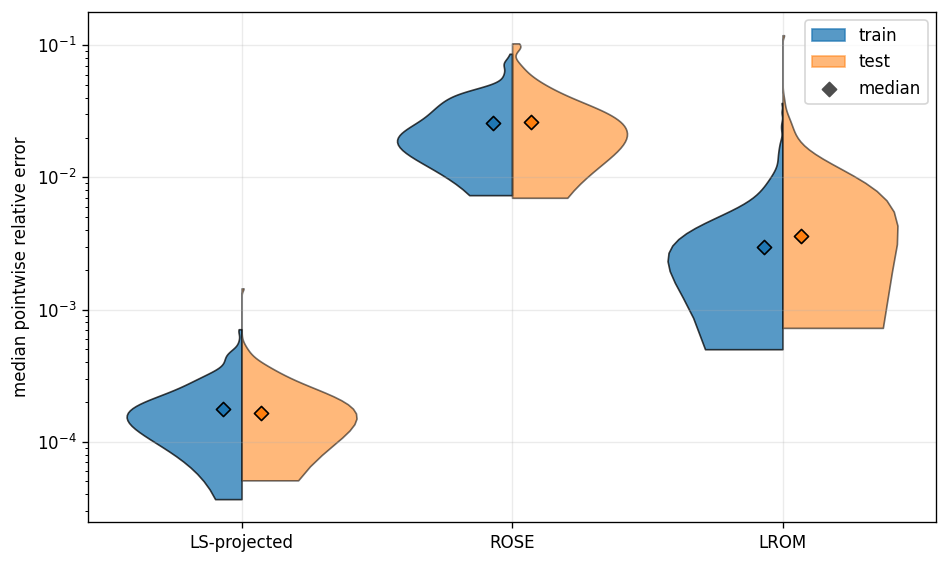

In [13]:
categories = (
    ("LS-projected", ls_results[DEFAULT_BASIS_SIZE]),
    ("ROSE", rose_results[default_key]),
    ("LROM", lrom_results[default_key]),
)
category_positions = np.arange(1, len(categories) + 1)
fig, ax = plt.subplots(figsize=(8.0, 4.8))

# Half violins retain raw dimensionless errors; only the display axis is logarithmic.
for center_position, (_, result) in zip(category_positions, categories):
    for side, key, color, opacity in (
        (-1, "train_median_over_angle_error", "tab:blue", 0.75),
        (+1, "test_median_over_angle_error", "tab:orange", 0.55),
    ):
        values = result[key]
        parts = ax.violinplot(
            [values],
            positions=[center_position],
            widths=0.85,
            showextrema=False,
        )
        body = parts["bodies"][0]
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = (
            np.minimum(vertices[:, 0], center_position)
            if side < 0
            else np.maximum(vertices[:, 0], center_position)
        )
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(opacity)
        ax.scatter(
            center_position + 0.07 * side,
            np.median(values),
            marker="D",
            color=color,
            edgecolor="black",
            zorder=6,
        )

ax.set_yscale("log", nonpositive="clip")
ax.yaxis.set_major_formatter(LOG_FORMATTER)
ax.set_xticks(category_positions, [label for label, _ in categories])
ax.set_ylabel("median pointwise relative error")
ax.fill_between([], [], color="tab:blue", alpha=0.75, label="train")
ax.fill_between([], [], color="tab:orange", alpha=0.55, label="test")
ax.scatter([], [], marker="D", color="0.3", label="median")
ax.legend()
fig.tight_layout()
plt.show()

In [14]:
# ROSE n_U counts EIM interaction functions; LROM N_U counts learned operator matrices.
summary_rows = []
for method, symbol, results in (
    ("ROSE", "n_U", rose_results),
    ("LROM", "N_U", lrom_results),
):
    for (n_phi, compression), result in results.items():
        summary_rows.append(
            {
                "method": method,
                "n_phi": n_phi,
                "compression symbol": symbol,
                "compression": compression,
                "median pointwise test error": float(
                    np.median(result["test_median_over_angle_error"])
                ),
                "median maximum-over-angle error": float(
                    np.median(result["test_maximum_over_angle_error"])
                ),
                "median online time [s]": float(np.median(result["test_seconds"])),
            }
        )

summary_table = pd.DataFrame(summary_rows).sort_values(
    ["method", "n_phi", "compression"]
)
summary_table

,method,n_phi,compression symbol,compression,median pointwise test error,median maximum-over-angle error,median online time [s]
9,LROM,4,N_U,4,0.062416,0.328690,0.000095
10,LROM,4,N_U,8,0.005586,0.028392,0.000104
11,LROM,4,N_U,12,0.002098,0.010115,0.000112
12,LROM,6,N_U,4,0.059096,0.311264,0.000111
13,LROM,6,N_U,8,0.003633,0.020615,0.000123
14,LROM,6,N_U,12,0.000510,0.002829,0.000133
15,LROM,8,N_U,4,0.071469,0.399395,0.000126
16,LROM,8,N_U,8,0.003479,0.019711,0.000140
17,LROM,8,N_U,12,0.000450,0.002360,0.000158
0,ROSE,4,n_U,4,0.145661,0.595075,0.000465


## 8. CAT Plot

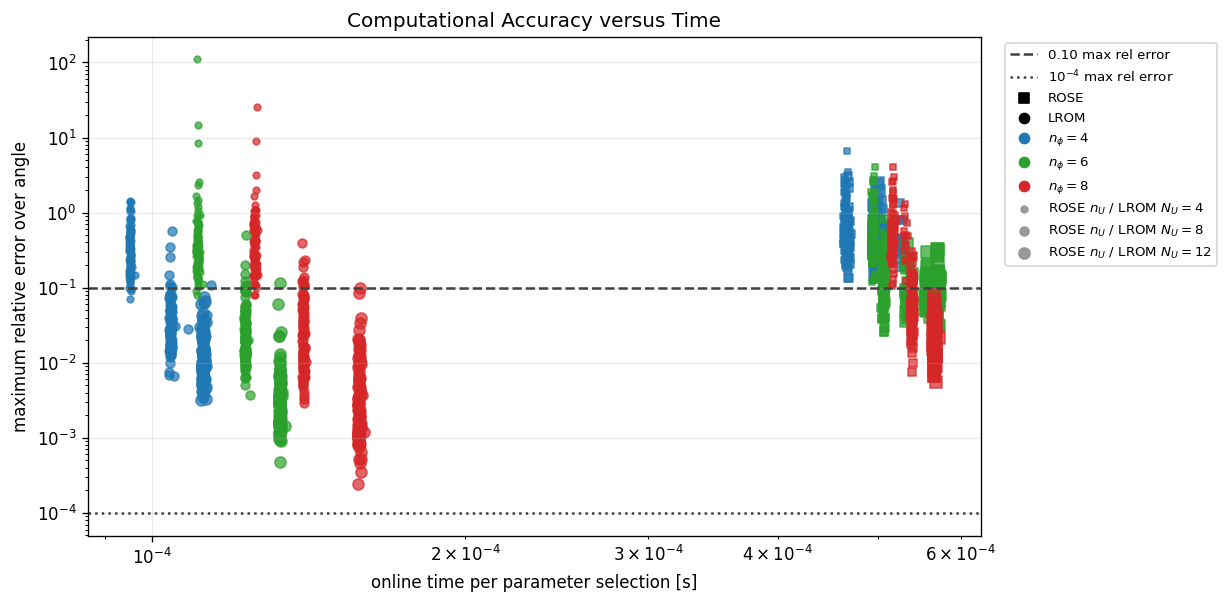

In [15]:
fig, ax = plt.subplots(figsize=(12.5, 5.4))
colors = dict(zip(BASIS_SIZES, ("tab:blue", "tab:green", "tab:red")))
compression_sizes = dict(zip(ROSE_EIM_SIZES, (16, 28, 44)))

for (n_phi, n_u), result in rose_results.items():
    ax.scatter(
        result["test_seconds"],
        result["test_maximum_over_angle_error"],
        marker="s", s=compression_sizes[n_u], alpha=0.7, color=colors[n_phi],
    )

for (n_phi, n_u), result in lrom_results.items():
    ax.scatter(
        result["test_seconds"],
        result["test_maximum_over_angle_error"],
        marker="o", s=compression_sizes[n_u], alpha=0.7, color=colors[n_phi],
    )

ax.axhline(0.10, color="0.25", linestyle="--", label="0.10 max rel error")
ax.axhline(1e-4, color="0.25", linestyle=":", label=r"$10^{-4}$ max rel error")
ax.set_xscale("log")
ax.set_yscale("log", nonpositive="clip")
ax.xaxis.set_major_formatter(LOG_FORMATTER)
ax.yaxis.set_major_formatter(LOG_FORMATTER)
ax.set_xlabel("online time per parameter selection [s]")
ax.set_ylabel("maximum relative error over angle")
ax.set_title("Computational Accuracy versus Time")

ax.scatter([], [], marker="s", color="black", label="ROSE")
ax.scatter([], [], marker="o", color="black", label="LROM")
for n_phi, color in colors.items():
    ax.scatter([], [], marker="o", color=color, label=rf"$n_\phi={n_phi}$")
for compression, size in compression_sizes.items():
    ax.scatter(
        [], [], marker="o", s=size, color="0.6",
        label=rf"ROSE $n_U$ / LROM $N_U={compression}$",
    )

ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=8)
fig.subplots_adjust(right=0.72)
plt.show()

Compact execution diagnostics replace execution-stopping performance claims.
validation_summary = pd.DataFrame(
    [
        {"check": "training rows", "value": train_rows.shape},
        {"check": "testing rows", "value": test_rows.shape},
        {"check": "ROSE/LROM shared rows", "value": True},
        {"check": "partial-wave channel counts", "value": rose_channel_counts},
        {"check": "EXFOR subentry", "value": "11611003"},
        {"check": "EXFOR points", "value": exfor_angles_cm.size},
        {"check": "EXFOR angle frame", "value": "center of mass"},
        {"check": "testing envelope cases", "value": N_TEST},
        {"check": "parameter half-width", "value": HALF_WIDTH},
        {"check": "basis sizes", "value": BASIS_SIZES},
        {"check": "ROSE EIM sizes n_U", "value": ROSE_EIM_SIZES},
        {"check": "LROM operator counts N_U", "value": LROM_OPERATOR_COUNTS},
        {"check": "matched predictor channels", "value": len(validated_predictor_radii)},
        {
            "check": "parked-v2 default median pointwise error",
            "value": default_old_v2_median_error,
        },
        {
            "check": "LROM default median pointwise error",
            "value": default_lrom_median_error,
        },
        {
            "check": "LS default median pointwise error",
            "value": float(
                np.median(
                    ls_results[DEFAULT_BASIS_SIZE]["test_median_over_angle_error"]
                )
            ),
        },
        {
            "check": "ROSE default median pointwise error",
            "value": float(
                np.median(rose_results[default_key]["test_median_over_angle_error"])
            ),
        },
        {"check": "LROM version", "value": lrom.__version__},
        {"check": "Python", "value": sys.version.split()[0]},
        {"check": "platform", "value": sys.platform},
    ]
)
validation_summary